In [45]:
import requests
import base64
from PIL import Image
from io import BytesIO
import torch
from torchvision.transforms import ToTensor

class Pi_Client:
    def __init__(self, url, handle='/get_last', **args):
        self.url = url
        self.handle = handle
        self.fractioner = Fractioner(args['boxes'], args['img_sz'])

    def get_data(self):
        try:
            response = requests.get(f"{self.url}{self.handle}")
            data = response.json()
        except err:
            print(f"API error {err}")
            return None

        if not data["ready"]:
            return None

        # если достучались до API и ответ готов то извлекаем данные
        tensor_list = []
        for img_info in data["images"]:
            base64_string = img_info["data"].split(",")[1]
            
            image_data = base64.b64decode(base64_string)
            
            image = Image.open(BytesIO(image_data))
            
            transform = ToTensor()
            tensor = transform(image)
            tensor_list.append(tensor)

        output = self.fractioner(tensor_list)
        return output


In [76]:
class Fractioner:
    # boxes опцианально задаются в пикселях или в пропорциях
    def __init__(self, boxes, img_sz=None):
        self.boxes = boxes
        if img_sz:
            self.boxes[0] = self.boxes[0]*img_sz[0]
            self.boxes[1] = self.boxes[1]*img_sz[1]
            self.boxes[2] = self.boxes[2]*img_sz[0]
            self.boxes[3] = self.boxes[3]*img_sz[1]
            self.boxes = self.boxes.int()

    def __call__(self, tensor_list):
        """
        returns two lists of tensors [object][sample]
        """
        heatmaps = []
        images = []

        for png in tensor_list:
            heatmap = png[3,:,:].unsqueeze(0)
            image = png[:3,:,:]
            
            heat_segments = []
            img_segments = []

            for y,x,h,w in self.boxes:
                heat_segments.append(heatmap[:,y:y+h,x:x+w])
                img_segments.append(image[:,y:y+h,x:x+w])

            heatmaps.append(heat_segments)
            images.append(img_segments)

        return heatmaps, images

    def show_samples(self, tensor_list, grid=(2,2), hmaps=False):
        import matplotlib.pyplot as plt

        heatmaps, images = self.__call__(tensor_list)
        
        fig, axs = plt.subplots(grid[0], grid[1], figsize=(grid[0]*4, grid[1]*4))
        for i, ax in enumerate(axs.flat):
            if hmaps:
                img = heatmaps[0][i][0]
            else:
                img = torch.permute(images[0][i], (1,2,0))
        
            ax.imshow(img)
            ax.axis('off')  # Отключаем оси
        
        plt.tight_layout()
        plt.show()
        

In [77]:
grid = torch.tensor([
    [0.0,0.0,0.2,0.3],
    [0.2,0.3,0.2,0.3],
    [0.4,0.6,0.3,0.2],
    [0.7,0.8,0.3,0.2] 
])#  y    x   h    w

img_sz = [500, 500]

test = Fractioner(grid, img_sz)
heatmaps, images = test(data)

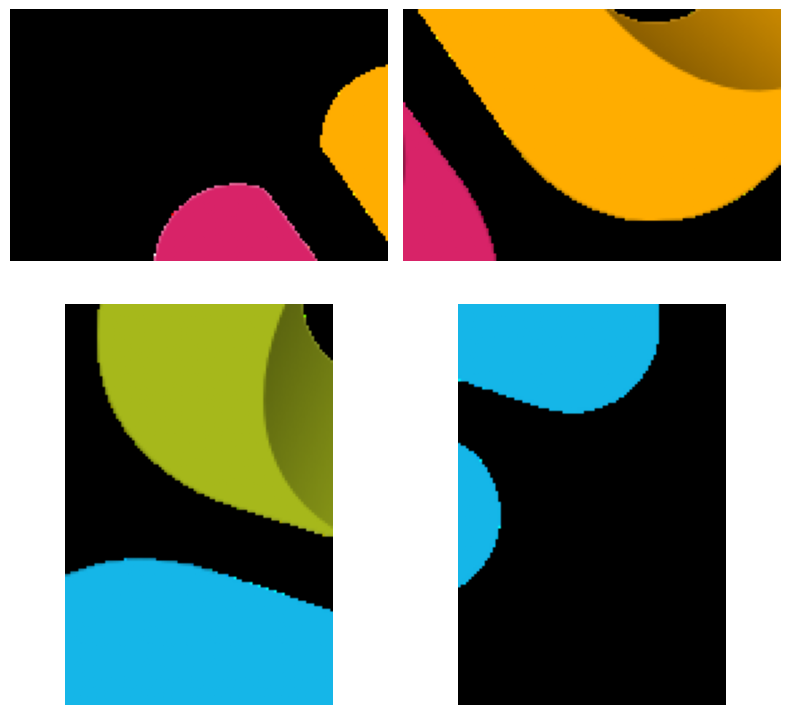

In [82]:
test.show_samples(data, hmaps=False)

In [66]:
import time

class Worker:
    def __init__(self, **args):
        self.client = Pi_Client(**args)
        # reshala

    def start(self):

    def stop(self):

    def run(self):
        while True:
            data = self.client.get_data()

            if data is None:
                time.sleep(0.5)
                continue
            else:
                print(self._solve(data))

    def _solve(self, data):
        
        

IndentationError: expected an indented block after function definition on line 8 (374232934.py, line 10)

In [46]:
client = Pi_Client("http://127.0.0.1:8001")
data = client.get_data()